<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Assignment8_revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================
# 1. SETUP
# =========================================
!pip install -q kagglehub

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import kagglehub
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)

IMG_SIZE = 64
LATENT_DIM = 64
BATCH_SIZE = 64
BETA = 1.0
EPOCHS = 30
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.19.0


In [2]:
# =========================================
# 2. LOAD DATASET + ATTRIBUTE FILE
# =========================================
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset path:", path)

IMG_DIR = os.path.join(path, "img_align_celeba", "img_align_celeba")

# use your uploaded CSV if present, otherwise fallback to kaggle copy
if os.path.exists("/content/list_attr_celeba.csv"):
    ATTR_PATH = "/content/list_attr_celeba.csv"
else:
    ATTR_PATH = os.path.join(path, "list_attr_celeba.csv")

attr_df = pd.read_csv(ATTR_PATH)

# convert -1/1 -> 0/1
attr_cols = [c for c in attr_df.columns if c != "image_id"]
attr_df[attr_cols] = (attr_df[attr_cols] == 1).astype(int)

print(attr_df.shape)
print(attr_df[["image_id", "Black_Hair", "Blond_Hair", "Male", "Smiling", "Young"]].head())

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset path: /kaggle/input/celeba-dataset
(202599, 41)
     image_id  Black_Hair  Blond_Hair  Male  Smiling  Young
0  000001.jpg           0           0     0        1      1
1  000002.jpg           0           0     0        1      1
2  000003.jpg           0           0     1        0      1
3  000004.jpg           0           0     0        0      1
4  000005.jpg           0           0     0        0      1


In [3]:
# =========================================
# 3. PROFESSOR-APPROVED SUBSET
#    black/blonde only, then sample <= 10k
# =========================================
hair_subset = attr_df[(attr_df["Black_Hair"] == 1) | (attr_df["Blond_Hair"] == 1)].copy()

# keep only files that exist
hair_subset["filepath"] = hair_subset["image_id"].apply(lambda x: os.path.join(IMG_DIR, x))
hair_subset = hair_subset[hair_subset["filepath"].apply(os.path.exists)].reset_index(drop=True)

# sample up to 10,000
max_n = min(10000, len(hair_subset))
hair_subset = hair_subset.sample(n=max_n, random_state=SEED).reset_index(drop=True)

print("Subset size:", len(hair_subset))
print(hair_subset[["Black_Hair", "Blond_Hair", "Male", "Smiling", "Young"]].mean())

Subset size: 10000
Black_Hair    0.6141
Blond_Hair    0.3859
Male          0.3424
Smiling       0.5261
Young         0.8483
dtype: float64


In [4]:
# =========================================
# 4. LOAD IMAGES INTO MEMORY
#    10k x 64x64 is manageable in Colab
# =========================================
def load_images_from_df(df, img_size=64):
    images = []
    valid_rows = []

    for _, row in df.iterrows():
        img = cv2.imread(row["filepath"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype("float32") / 255.0
        images.append(img)
        valid_rows.append(row)

    images = np.array(images, dtype=np.float32)
    out_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    return images, out_df

images_all, labels_all = load_images_from_df(hair_subset, IMG_SIZE)

print("Images shape:", images_all.shape)
print("Labels shape:", labels_all.shape)

Images shape: (10000, 64, 64, 3)
Labels shape: (10000, 42)


In [5]:
# =========================================
# 5. TRAIN / VAL / TEST SPLIT
# =========================================
idx = np.arange(len(images_all))

train_idx, test_idx = train_test_split(idx, test_size=0.10, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1111, random_state=SEED)  # ~10% val overall

x_train = images_all[train_idx]
x_val   = images_all[val_idx]
x_test  = images_all[test_idx]

labels_train = labels_all.iloc[train_idx].reset_index(drop=True)
labels_val   = labels_all.iloc[val_idx].reset_index(drop=True)
labels_test  = labels_all.iloc[test_idx].reset_index(drop=True)

print(x_train.shape, x_val.shape, x_test.shape)

(8000, 64, 64, 3) (1000, 64, 64, 3) (1000, 64, 64, 3)


In [6]:
# =========================================
# 6. tf.data PIPELINE
# =========================================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(len(x_train), seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices(x_val).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [7]:
# =========================================
# 7. VAE MODEL
#    use the deeper architecture
# =========================================
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_encoder(latent_dim=LATENT_DIM):
    encoder_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="encoder_input")
    x = layers.Conv2D(32, 4, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = layers.Conv2D(64, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])

    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

def build_decoder(latent_dim=LATENT_DIM):
    latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
    x = layers.Dense(4 * 4 * 256, activation="relu")(latent_inputs)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 4, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2DTranspose(3, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(latent_inputs, outputs, name="decoder")

encoder = build_encoder()
decoder = build_decoder()

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,568 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     32,832 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │    131,200 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 256) │    524,544 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,664 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │     32,832 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │     32,832 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 64)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,853,472 (10.89 MB)

 Trainable params: 2,853,472 (10.89 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     1,048,832 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,004,291 (7.65 MB)

 Trainable params: 2,004,291 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================================
# 8. CUSTOM VAE
# =========================================
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def compute_losses(self, images, training=False):
        z_mean, z_log_var, z = self.encoder(images, training=training)
        reconstruction = self.decoder(z, training=training)

        recon_per_pixel = keras.losses.binary_crossentropy(images, reconstruction)
        recon_loss = tf.reduce_mean(tf.reduce_sum(recon_per_pixel, axis=(1, 2)))

        kl_term = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_term, axis=1))

        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        images = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_losses(images, training=True)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        images = data
        total_loss, recon_loss, kl_loss = self.compute_losses(images, training=False)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs, training=False):
        _, _, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

vae = VAE(encoder, decoder, beta=BETA)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))

In [9]:
# =========================================
# 9. TRAIN
# =========================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - kl_loss: 2.7046 - loss: 2800.8577 - recon_loss: 2798.1533 - val_kl_loss: 9.9289 - val_loss: 2658.5210 - val_recon_loss: 2648.5918
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - kl_loss: 15.0346 - loss: 2578.6033 - recon_loss: 2563.5684 - val_kl_loss: 34.6181 - val_loss: 2407.6750 - val_recon_loss: 2373.0566
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - kl_loss: 33.9447 - loss: 2369.0796 - recon_loss: 2335.1353 - val_kl_loss: 34.8254 - val_loss: 2356.6736 - val_recon_loss: 2321.8477
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - kl_loss: 36.2339 - loss: 2316.9473 - recon_loss: 2280.7136 - val_kl_loss: 37.7468 - val_loss: 2322.9495 - val_recon_loss: 2285.2026
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - kl_loss: 38.4012 - loss: 2296.4106 - recon_loss: 2258.0090 - val_kl_loss: 39.2600 - val_loss: 2305.0984 - val_recon_loss: 2265.8384
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - kl_loss: 40.

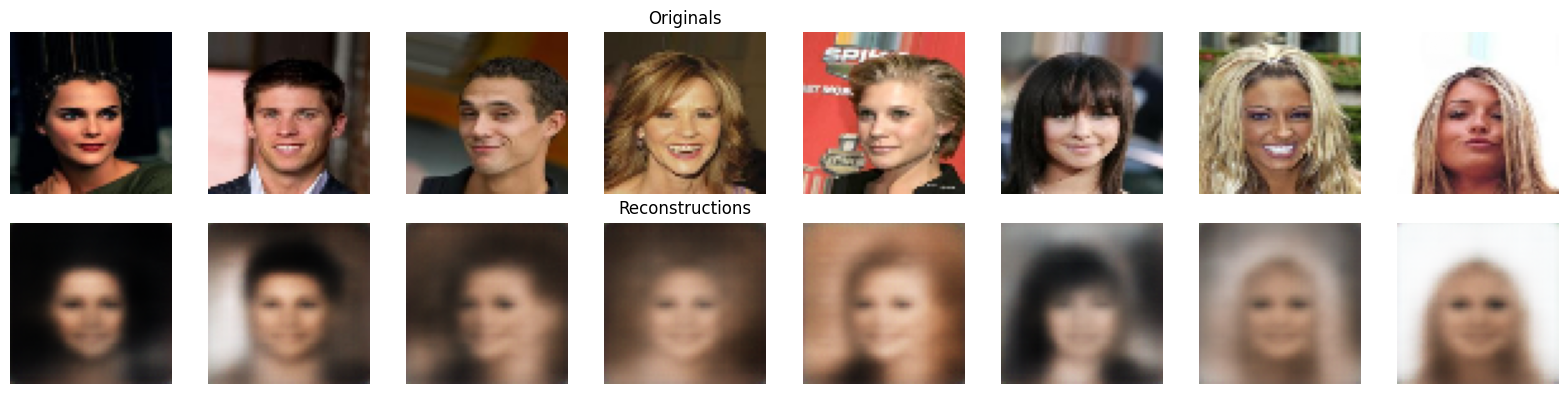

In [10]:
# =========================================
# 10. RECONSTRUCTIONS
# =========================================
def reconstruct_images(encoder, decoder, images):
    z_mean, _, _ = encoder(images, training=False)
    return decoder(z_mean, training=False)

sample_batch = x_test[:8]
recons = reconstruct_images(encoder, decoder, sample_batch).numpy()

plt.figure(figsize=(16, 4))
for i in range(8):
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_batch[i])
    plt.axis("off")
    if i == 3:
        plt.title("Originals")

    ax = plt.subplot(2, 8, i + 9)
    plt.imshow(np.clip(recons[i], 0, 1))
    plt.axis("off")
    if i == 3:
        plt.title("Reconstructions")
plt.tight_layout()
plt.show()

In [11]:
# =========================================
# 11. ATTRIBUTE VECTORS
#    use z_mean, not sampled z
# =========================================
def get_balanced_indices(labels_df, pos_mask, neg_mask, max_samples=1500, seed=SEED):
    pos_idx = np.where(pos_mask)[0]
    neg_idx = np.where(neg_mask)[0]
    n = min(len(pos_idx), len(neg_idx), max_samples)

    rng = np.random.default_rng(seed)
    pos_idx = rng.choice(pos_idx, size=n, replace=False)
    neg_idx = rng.choice(neg_idx, size=n, replace=False)
    return pos_idx, neg_idx

def encode_means(images, batch_size=128):
    z_means = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        z_mean, _, _ = encoder(batch, training=False)
        z_means.append(z_mean.numpy())
    return np.concatenate(z_means, axis=0)

def compute_attribute_vector(images, labels_df, positive_attr, negative_attr=None, max_samples=1500):
    if negative_attr is None:
        pos_mask = labels_df[positive_attr].values == 1
        neg_mask = labels_df[positive_attr].values == 0
    else:
        pos_mask = labels_df[positive_attr].values == 1
        neg_mask = labels_df[negative_attr].values == 1

    pos_idx, neg_idx = get_balanced_indices(labels_df, pos_mask, neg_mask, max_samples=max_samples)

    z_pos = encode_means(images[pos_idx])
    z_neg = encode_means(images[neg_idx])

    vec = z_pos.mean(axis=0, keepdims=True) - z_neg.mean(axis=0, keepdims=True)
    return vec

attribute_vectors = {
    "Male": compute_attribute_vector(x_train, labels_train, "Male"),
    "Smiling": compute_attribute_vector(x_train, labels_train, "Smiling"),
    "Young": compute_attribute_vector(x_train, labels_train, "Young"),
    "Black_to_Blonde": compute_attribute_vector(x_train, labels_train, "Blond_Hair", "Black_Hair"),
}

for k, v in attribute_vectors.items():
    print(k, v.shape)

Male (1, 64)
Smiling (1, 64)
Young (1, 64)
Black_to_Blonde (1, 64)


In [12]:
# =========================================
# 12. APPLY ATTRIBUTE
# =========================================
def edit_image(image, attr_vector, strength=2.0):
    image_batch = np.expand_dims(image, axis=0)
    z_mean, _, _ = encoder(image_batch, training=False)
    edited = decoder(z_mean + strength * attr_vector, training=False)
    return edited[0].numpy()

def choose_source_image(images, labels_df, attr_name):
    if attr_name == "Male":
        # choose female
        candidates = np.where(labels_df["Male"].values == 0)[0]
    elif attr_name == "Smiling":
        candidates = np.where(labels_df["Smiling"].values == 0)[0]
    elif attr_name == "Young":
        candidates = np.where(labels_df["Young"].values == 0)[0]
    elif attr_name == "Black_to_Blonde":
        candidates = np.where(labels_df["Black_Hair"].values == 1)[0]
    else:
        raise ValueError("Unknown attribute")

    idx = np.random.choice(candidates)
    return images[idx], idx

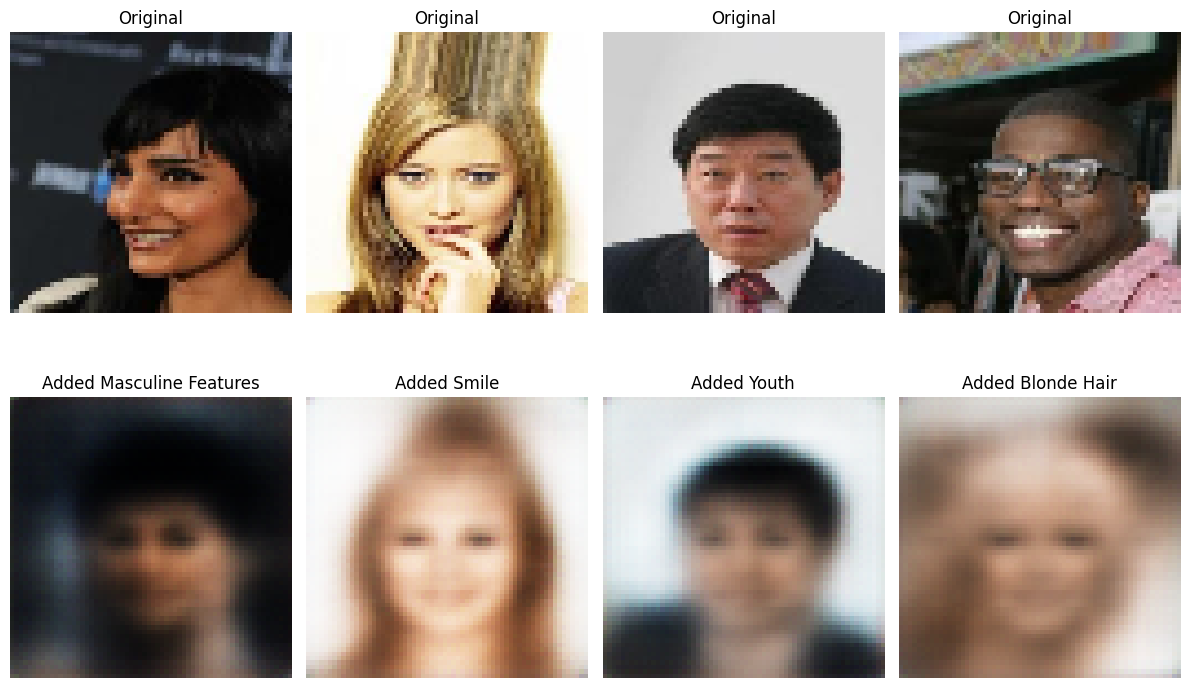

In [13]:
# =========================================
# 13. FINAL VISUALS
# =========================================
display_plan = [
    ("Male", "Added Masculine Features", 2.0),
    ("Smiling", "Added Smile", 2.0),
    ("Young", "Added Youth", 2.0),
    ("Black_to_Blonde", "Added Blonde Hair", 2.0),
]

plt.figure(figsize=(12, 8))

for i, (attr_key, title, alpha) in enumerate(display_plan):
    original, idx = choose_source_image(x_test, labels_test, attr_key)
    edited = edit_image(original, attribute_vectors[attr_key], strength=alpha)

    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(original, 0, 1))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(np.clip(edited, 0, 1))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()